# $g_2$ deviation comparison

Explore the effect of the EFT $g_2$ coupling on oscillon observables.

Three main diagnostics:
1. **Scalar field** $\phi_c$ vs $\ln(a)$ — central field evolution
2. **Energy density** $\rho(r)$ vs $r$ — radial profile at chosen snapshots
3. **Compactness** $\mathcal{C}$ vs $\ln(a)$ — time evolution

Runs can be filtered by $\lambda_{\rm GB}$ and $g_2$, or overlaid on the same plot.

In [1]:
import sys, os, re, glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic
from bssn.EFTdiagnostic import get_eft_diagnostic

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
print(f"DATA_DIR = {DATA_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs


/vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/bssn/EFTdiagnostic.py:93: SyntaxWarning: invalid escape sequence '\m'
  """


## 0 — Parameters

In [2]:
ALIGN_LNA = 2.0
ALIGN_METHOD = "last_cross"
LNA_MIN_SEARCH = 0.0

C_CROSS_LEVELS = {
    -0.02: 0.02,
    -0.05: 0.04,
    -0.1:  0.06,
    -0.5:  0.125,
}
C_CROSS_DEFAULT = 0.02

# This gives the time window over which you want to take the average to calculate the compactness
# and the mean.
LN_A_COMP_MIN = 2
LN_A_COMP_MAX = 3.6

scalar_mu = 1
r_max = 150
min_dr = 1 / 16
max_dr = 2
a_mg = 0.2
b_mg = 0.4
chi0 = 0.15

## 1 — Discover, load, and align all runs

Run key is now `(lgb, mu, beta, amp, width, g2)` to separate runs with different $g_2$.

In [3]:
def find_peak_lna(osc, lna_min=0.0):
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

def find_last_crossing_lna(osc, level, lna_min=0.0):
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    C_sub = C[idx]
    ln_a_sub = ln_a[idx]
    above = C_sub > level
    crossings = np.where(above[:-1] & ~above[1:])[0]
    if len(crossings) == 0:
        return np.nan
    last = crossings[-1]
    frac = (level - C_sub[last+1]) / (C_sub[last] - C_sub[last+1])
    return ln_a_sub[last] * frac + ln_a_sub[last+1] * (1 - frac)

def compactness_in_window(shifted_ln_a, C, lo=LN_A_COMP_MIN, hi=LN_A_COMP_MAX):
    mask = (shifted_ln_a >= lo) & (shifted_ln_a <= hi)
    if not np.any(mask):
        return np.nan, np.nan, np.nan, np.nan
    c = C[mask]
    return np.mean(c), np.min(c), np.max(c), np.std(c)


######## LOADING FILTERS ########
FILTER_A_MG = 0
FILTER_B_MG = 0
FILTER_DR   = 1/24
#1/36  # set to None to load all resolutions, or e.g. 1/24, 1/36
############################

all_runs = {}   # key = (lgb, mu, beta, amp, width, g2)

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0

    m_a = re.search(r"_a([0-9eE.+-]+)_b", tag)
    m_b = re.search(r"_b([0-9eE.+-]+)_amp", tag)
    tag_a = float(m_a.group(1)) if m_a else 0.2
    tag_b = float(m_b.group(1)) if m_b else 0.4

    m_dr = re.search(r"_dr([0-9eE.+-]+)", tag)
    tag_dr = float(m_dr.group(1)) if m_dr else 0.0625

    if FILTER_A_MG is not None and abs(tag_a - FILTER_A_MG) > 1e-10:
        continue
    if FILTER_B_MG is not None and abs(tag_b - FILTER_B_MG) > 1e-10:
        continue
    if FILTER_DR is not None and abs(tag_dr - FILTER_DR) > 1e-4:
        continue

    m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
    if m_beta:
        beta = float(m_beta.group(1))
    elif re.search(r"_quadratic_g2", tag) or tag.endswith("_quadratic"):
        beta = 0.0
    else:
        beta = 250.0

    if "_linear" in tag:
        coupling = "linear"; beta = None
    elif m_beta:
        coupling = f"quadratic_{int(beta)}"
    else:
        coupling = "quadratic"

    # Extract g2: first from directory name, then from metadata, default 0.0
    g2_val = 0.0
    m_g2 = re.search(r"_g2([0-9eE.+-]+)", tag)
    if m_g2:
        g2_val = float(m_g2.group(1))
    else:
        meta_path = os.path.join(run_dir, "metadata.npz")
        if os.path.exists(meta_path):
            try:
                meta = dict(np.load(meta_path, allow_pickle=True))
                if "g2" in meta:
                    g2_val = float(meta["g2"])
            except Exception:
                pass

    # Grid must match the run that wrote solution.npy (notebook r_max/min_dr alone can differ).
    _meta_for_grid = os.path.join(run_dir, "metadata.npz")
    _meta_grid = dict(np.load(_meta_for_grid, allow_pickle=True)) if os.path.exists(_meta_for_grid) else {}
    run_r_max = float(_meta_grid.get("r_max", r_max))
    run_min_dr = float(_meta_grid.get("min_dr", tag_dr))
    run_max_dr = float(_meta_grid.get("max_dr", max_dr))

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(run_r_max, run_min_dr, run_max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)

    _npt = sol[0].ravel().size // sv_i.NUM_VARS
    if _npt != grid_i.num_points:
        raise ValueError(
            f"{tag}: solution N={_npt} vs grid N={grid_i.num_points} "
            f"(r_max={run_r_max}, min_dr={run_min_dr}). Check metadata or tag_dr."
        )

    params = (lgb, a_mg, b_mg, chi0, coupling, g2_val)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
    else:
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(diag_path, **osc)

    # Alignment
    if ALIGN_METHOD == "last_cross":
        cross_level = C_CROSS_LEVELS.get(amp, C_CROSS_DEFAULT)
        anchor_lna = find_last_crossing_lna(osc, level=cross_level, lna_min=LNA_MIN_SEARCH)
    else:
        anchor_lna = find_peak_lna(osc, lna_min=LNA_MIN_SEARCH)
    shift = ALIGN_LNA - anchor_lna if not np.isnan(anchor_lna) else 0.0
    shifted_ln_a = osc["ln_a"] + shift

    C_mean, C_min, C_max, C_std = compactness_in_window(shifted_ln_a, osc["C"])

    key = (lgb, mu, beta, amp, width, g2_val)
    all_runs[key] = dict(
        osc=osc, t=t, tag=tag, lgb=lgb, mu=mu, beta=beta,
        coupling=coupling, amp=amp, width=width, g2=g2_val, dr=tag_dr,
        shift=shift, shifted_ln_a=shifted_ln_a,
        C_mean=C_mean, C_min=C_min, C_max=C_max, C_std=C_std,
        run_dir=run_dir, run_r_max=run_r_max, run_min_dr=run_min_dr,
        run_max_dr=run_max_dr,
    )

    beta_str = f"beta={int(beta)}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, g2={g2_val:g}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}  "
              f"shift={shift:+.3f}  C: no data in window  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, g2={g2_val:g}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}  "
              f"shift={shift:+.3f}  C={C_mean:.4e} [{C_min:.4e}, {C_max:.4e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded and aligned")

  lgb=  -1.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.538  C=7.3091e-03 [4.3339e-03, 1.4466e-02]  (1000 steps)
  lgb=  -2.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.536  C=7.2257e-03 [4.2847e-03, 1.3609e-02]  (1000 steps)
  lgb=  -3.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.531  C=7.1473e-03 [4.2228e-03, 1.3554e-02]  (1000 steps)
  lgb=  -4.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.526  C=7.0565e-03 [4.1713e-03, 1.3361e-02]  (1000 steps)
  lgb=  -5.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.524  C=6.9630e-03 [4.1293e-03, 1.3226e-02]  (1000 steps)
  lgb=  -6.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.490  C=6.8973e-03 [4.1234e-03, 1.2932e-02]  (1000 steps)
  lgb=  -7.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.480  C=6.8087e-03 [4.0823e-03, 1.2883e-02]  (1000 steps)
  lgb=  -8.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.475  C=6.7250e-03 [4.0308e-03, 1.2720e-02]  (1000 steps)
  lgb=  

## 2 — Parameter catalogue

In [4]:
all_lgb    = sorted(set(k[0] for k in all_runs))
all_mu     = sorted(set(k[1] for k in all_runs))
all_beta   = sorted(set(k[2] for k in all_runs if k[2] is not None))
all_amp    = sorted(set(k[3] for k in all_runs))
all_width  = sorted(set(k[4] for k in all_runs))
all_g2     = sorted(set(k[5] for k in all_runs))

print(f"lambda_GB values: {all_lgb}")
print(f"g2 values:        {all_g2}")
print(f"mu values:        {all_mu}")
print(f"beta values:      {all_beta}")
print(f"amplitude values: {all_amp}")
print(f"width values:     {all_width}")

lambda_GB values: [-9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
g2 values:        [-10.0, -5.0, -4.0, -3.0, -2.0, -1.0, -0.5, 0.0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 20.0, 25.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 40.0, 50.0]
mu values:        [0.08]
beta values:      [0.0]
amplitude values: [-1.0, -0.5, -0.1, -0.05, -0.02]
width values:     [3.0]


## 3 — Select runs to plot

Filter which `(lgb, mu, beta, amp, width, g2)` keys appear on the plots.
Adjust the lists below to change the selection.

In [5]:
import importlib
import bssn.EFTdiagnostic as _eft_mod
importlib.reload(_eft_mod)
from bssn.EFTdiagnostic import get_eft_diagnostic


DEFAULT_AMP   = -0.02
DEFAULT_WIDTH = 3.0

#amps  = [-0.02, -0.05, -0.1, -0.5]
amps  = [-0.02]
betas = [0]  # 250 is the default when tag has no quadratic_N suffix (e.g. g2 runs)
mu_values = [0.08]
g2_select = [0, 0.1,20]
#[0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 20.0]
#[-10.0, -5.0, -4.0, -3.0, -2.0, -1.0, -0.5]
#[0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 20.0, 50.0]
#[0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]#all_g2  # all available g2 values

#FILTER_DR_SEL = 1/24
FILTER_DR_SEL = FILTER_DR

selected = [
    k for k in all_runs
    if k[2] in betas
    and 1> k[0] > -1
    and k[1] in mu_values
    and k[3] in amps
    and k[4] == DEFAULT_WIDTH
    and k[5] in g2_select
    and abs(all_runs[k]["dr"] - FILTER_DR_SEL) < 1e-4
]

"""
# Deduplicate: if both beta=0 and beta=250 exist for the same
# (lgb, mu, amp, width, g2), keep only beta=0 (they give identical physics).
seen = {}
for k in selected:
    lgb, mu, beta, amp, width, g2 = k
    base = (lgb, mu, amp, width, g2)
    if base not in seen or (beta == 0):
        seen[base] = k
selected = list(seen.values())
"""
keys_to_plot = sorted(selected, key=lambda k: tuple(x if x is not None else -999 for x in k))
print(f"{len(keys_to_plot)} run(s) selected")
for k in keys_to_plot:
    d = all_runs[k]
    print(f"  {k}  coupling={d['coupling']:<12s}  g2={d['g2']:g}  shift={d['shift']:+.3f}  C_mean={d['C_mean']:.4e}")

# --- Compute / load EFT diagnostics only for the selected runs ---
# Set FORCE_EFT_RECOMPUTE = True to ignore any cached .npz on disk and the
# in-memory "eft" field, recompute from scratch, and overwrite the cache.
FORCE_EFT_RECOMPUTE = True

for k in keys_to_plot:
    d = all_runs[k]
    if "eft" in d and not FORCE_EFT_RECOMPUTE:
        continue
    run_dir = d["run_dir"]
    eft_path = os.path.join(run_dir, "eft_diagnostics.npz")
    if os.path.exists(eft_path) and not FORCE_EFT_RECOMPUTE:
        d["eft"] = dict(np.load(eft_path, allow_pickle=True))
        print(f"  [EFT] loaded cache for {d['tag']}")
    else:
        sol = np.load(os.path.join(run_dir, "solution.npy"))
        matter_i  = ScalarMatter(scalar_mu, d["mu"])
        sv_i      = StateVector(matter_i)
        spacing_i = CubicSpacing(**CubicSpacing.get_parameters(
            d["run_r_max"], d["run_min_dr"], d["run_max_dr"]))
        grid_i    = Grid(spacing_i, sv_i)
        bg_i      = FlatSphericalBackground(grid_i.r)
        lgb_k, mu_k, beta_k, amp_k, width_k, g2_k = k
        params = (lgb_k, a_mg, b_mg, chi0, d["coupling"], g2_k)
        eft = get_eft_diagnostic(
            sol, d["t"], grid_i, bg_i,
            ScalarMatter(scalar_mu, d["mu"]),
            params,
        )
        np.savez(eft_path, **eft)
        d["eft"] = eft
        del sol
        verb = "recomputed" if FORCE_EFT_RECOMPUTE else "computed"
        print(f"  [EFT] {verb} & cached for {d['tag']}")

3 run(s) selected
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling=quadratic     g2=0  shift=+0.093  C_mean=3.9556e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.1)  coupling=quadratic     g2=0.1  shift=+0.098  C_mean=3.9735e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 20.0)  coupling=quadratic     g2=20  shift=+0.539  C_mean=7.3907e-03
  [EFT] recomputed & cached for lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  [EFT] recomputed & cached for lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20.1
  [EFT] recomputed & cached for lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g220


## 4 — Compactness $\mathcal{C}$ vs $\ln(a)$

All curves use `shifted_ln_a` computed during loading.

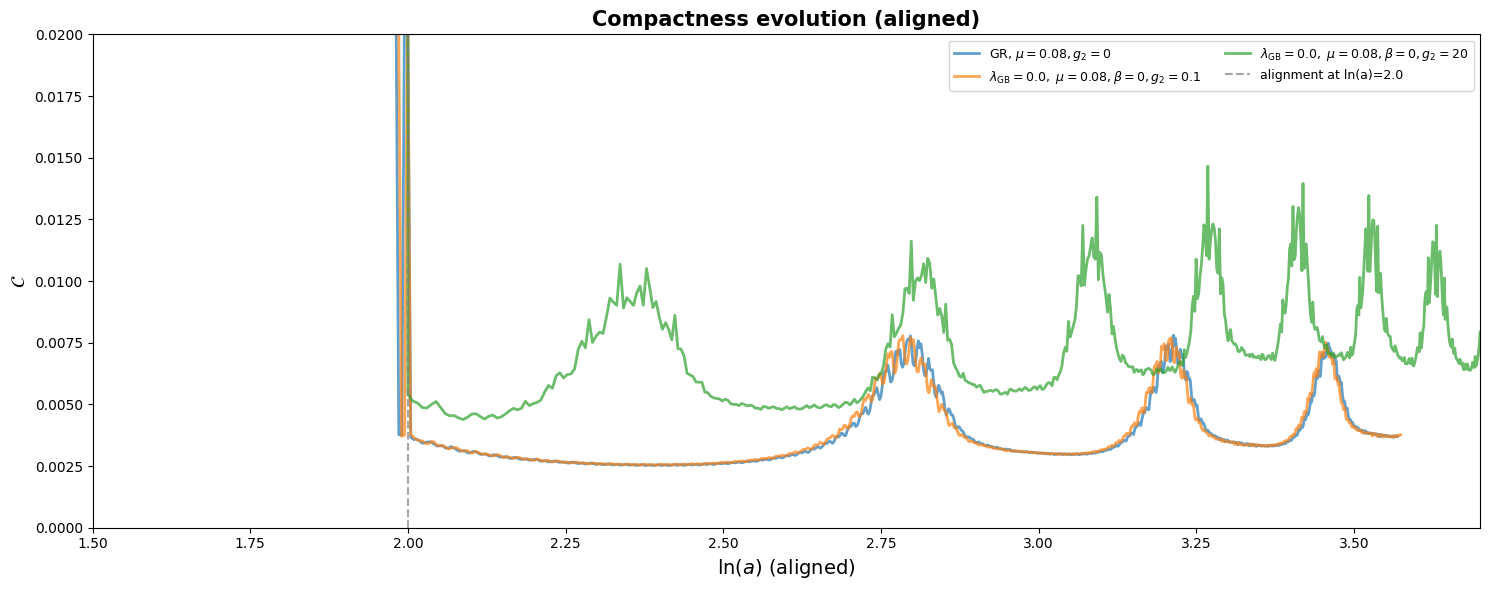

In [6]:
USE_ALIGNED = True

fig, ax = plt.subplots(figsize=(15, 6))
cmap = plt.cm.tab10
n_runs = len(keys_to_plot)


gr_key = (0.0, 0.08, 0.0, DEFAULT_AMP, DEFAULT_WIDTH, 0.0)

if gr_key in all_runs and gr_key not in keys_to_plot:
    gr = all_runs[gr_key]
    xgr = gr["shifted_ln_a"] if USE_ALIGNED else gr["osc"]["ln_a"]
    ax.plot(xgr, gr["osc"]["C"], color="k", lw=3, label="GR", alpha=1)

for i, key in enumerate(keys_to_plot):
    if key not in all_runs:
        continue
    data = all_runs[key]
    lgb, mu, beta, amp, width, g2 = key

    beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
    g2_str = rf", g_2={g2:g}"
    if lgb == 0.0 and g2 == 0.0:
        label = rf"GR, $\mu={mu}{g2_str}$"
    else:
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str}{g2_str}$"

    color = cmap(i % 10)
    xdata = data["shifted_ln_a"] if USE_ALIGNED else data["osc"]["ln_a"]
    ax.plot(xdata, data["osc"]["C"], color=color, lw=2, label=label, alpha=0.7)

if USE_ALIGNED:
    ax.axvline(ALIGN_LNA, color="grey", ls="--", lw=1.5, alpha=0.7,
               label=f"alignment at ln(a)={ALIGN_LNA}")

ax.set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED else ""), fontsize=14)
ax.set_ylabel(r"$\mathcal{C}$", fontsize=14)
ax.set_xlim(1.5, 3.7)
ax.set_ylim(0, 0.02)
ax.set_title("Compactness evolution" + (" (aligned)" if USE_ALIGNED else ""),
             fontsize=15, fontweight="bold")
ax.legend(fontsize=9, ncol=2, loc="upper right")
fig.tight_layout()
plt.show()

## 5 — Mean compactness vs $g_2$

Mean compactness (with std error bars) as a function of $g_2$, computed over
the window $[$`LN_A_COMP_MIN`, `LN_A_COMP_MAX`$]$. One curve per $\lambda_{\rm GB}$ value.

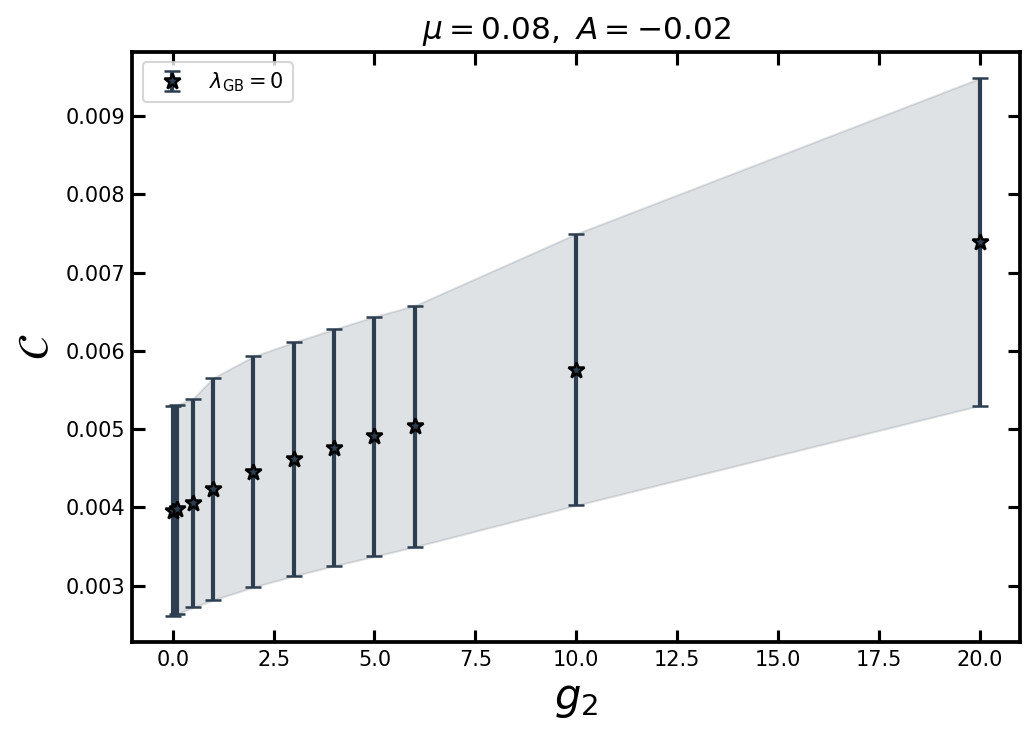

In [13]:
SAVE_PDF = False

plt.rcParams.update({
    "axes.linewidth": 1.8,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

from collections import defaultdict

amp_val = -0.02
lgb_show = [0]          # which lambda_GB values to plot
g2_show  = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 20.0]
#all_g2       # which g2 values to include on the x-axis

colors_lgb  = ["#2c3e50", "#c0392b", "#2980b9", "#f1c40f", "#8e44ad",
               "#e67e22", "#1abc9c", "#34495e", "#e74c3c", "#27ae60"]
markers_lgb = ["*", "s", "D", "^", "v", "<", ">", "P", "X", "o"]

fig, ax = plt.subplots(figsize=(7, 5))

lgb_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if amp != amp_val or mu not in mu_values:
        continue
    if lgb not in lgb_show or g2 not in g2_show:
        continue
    lgb_groups[lgb].append(key)

all_lgbs = sorted(lgb_groups.keys())

for idx, lgb_val in enumerate(all_lgbs):
    color  = colors_lgb[idx % len(colors_lgb)]
    marker = markers_lgb[idx % len(markers_lgb)]

    points = []
    for key in lgb_groups[lgb_val]:
        d = all_runs[key]
        if np.isnan(d["C_mean"]):
            continue
        points.append((key[5], d["C_mean"], d["C_std"]))

    if not points:
        continue

    points = sorted(points, key=lambda p: p[0])
    x      = np.array([p[0] for p in points])
    y_mean = np.array([p[1] for p in points])
    y_std  = np.array([p[2] for p in points])

    label = rf"$\lambda_{{\rm GB}}={lgb_val:g}$"

    ax.fill_between(x, y_mean - y_std, y_mean + y_std, color=color, alpha=0.15)
    ax.errorbar(x, y_mean, yerr=y_std,
                fmt=marker, color=color,
                markeredgecolor="k", markeredgewidth=1.2,
                capsize=4, capthick=1.2, elinewidth=2, markersize=8,
                label=label)

ax.set_xlabel(r"$g_2$", fontsize=20)
ax.set_ylabel(r"$\mathcal{C}$", fontsize=20)
ax.set_title(rf"$\mu={mu_values[0]},\ A={amp_val}$", fontsize=15)
ax.legend(fontsize=10, loc="best")
ax.tick_params(which="both", top=True, right=True)
fig.tight_layout()

if SAVE_PDF:
    fig.savefig("compactness_vs_g2.pdf", bbox_inches="tight")
    print("Saved compactness_vs_g2.pdf")

plt.show()

## 6 — Energy density $\rho(r)$ vs radius

Radial profile at chosen snapshots. All $g_2$ values for the chosen
`(lgb, mu, beta, amp, width)` are overlaid with different linestyles.

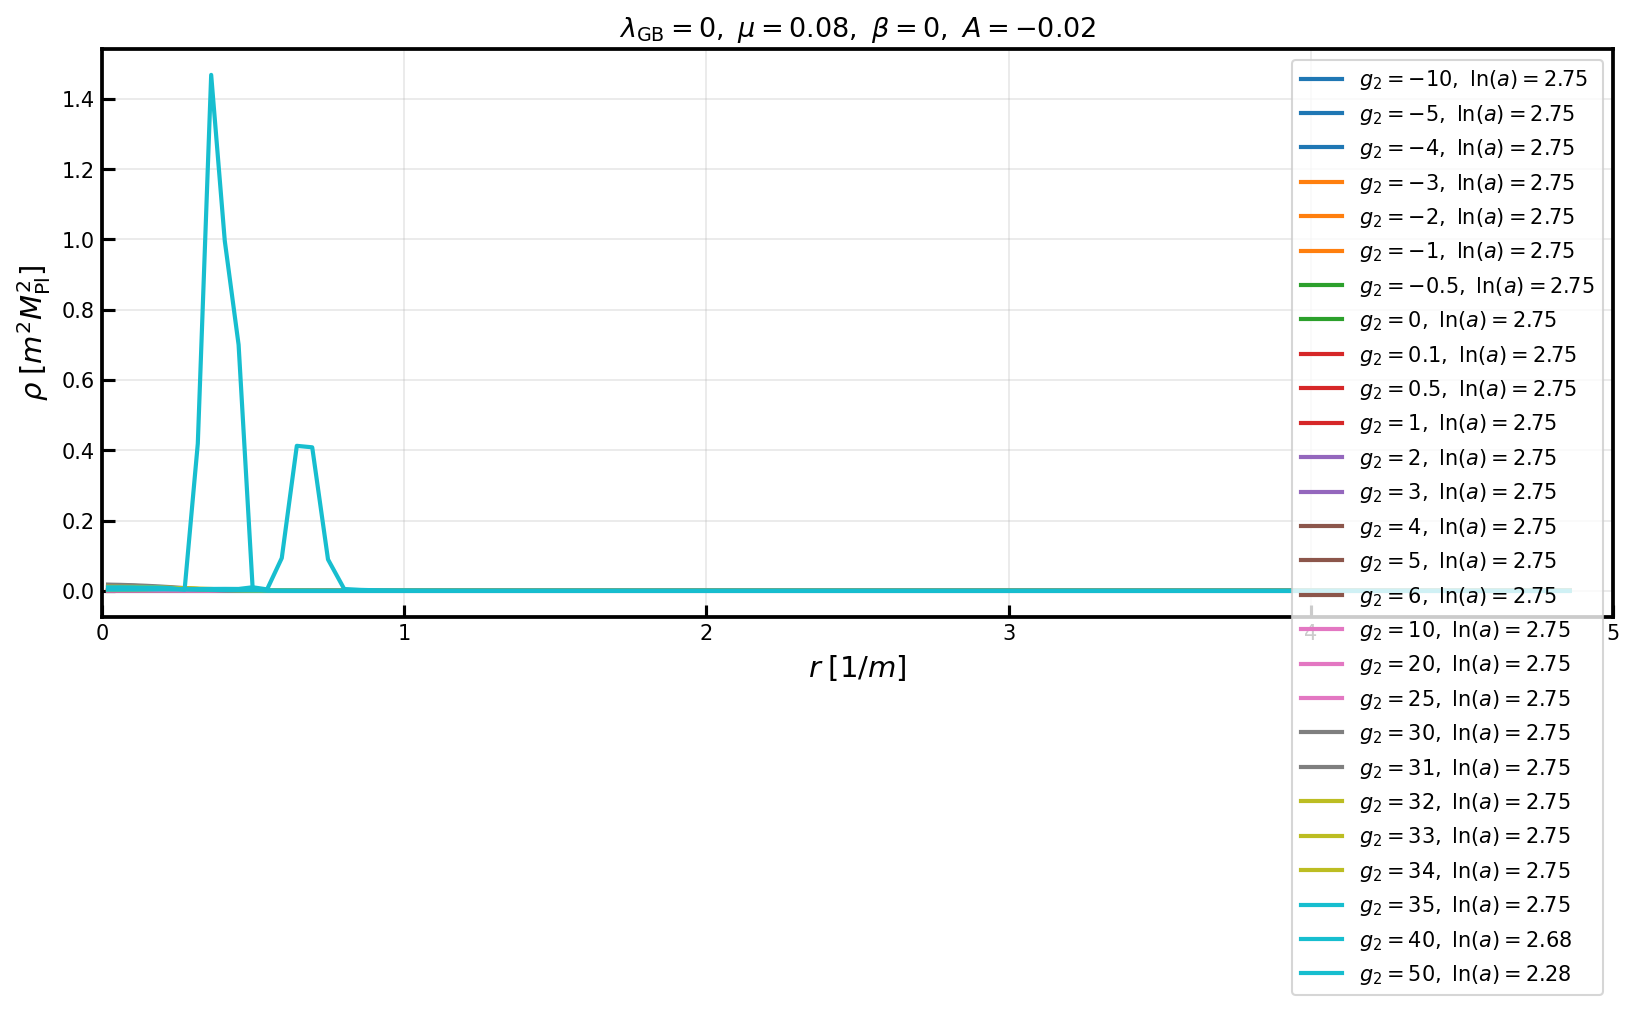

In [14]:
# ── Choose parameter combination ──────────────────────────────────────────
lgb_plot   = 0
mu_plot    = 0.08
beta_plot  = 0
amp_plot   = DEFAULT_AMP
width_plot = DEFAULT_WIDTH

# ── Snapshot selection (shifted ln(a) values) ─────────────────────────────
#snapshot_lna_values = [2.0, 2.25, 2.5, 3.0]
snapshot_lna_values = [2.75]
r_plot_max = 5

USE_OSCILLON_RADIUS = False

# ── Collect matching runs ─────────────────────────────────────────────────
matching_runs = []
for key in sorted(all_runs.keys(), key=lambda k: tuple(x if x is not None else -999 for x in k)):
    lgb, mu, beta, amp, width, g2 = key
    if lgb != lgb_plot or mu != mu_plot or amp != amp_plot or width != width_plot:
        continue
    if beta != beta_plot:
        continue
    matching_runs.append((key, all_runs[key]))

# Color per g2 value, linestyle per snapshot time
n_runs = len(matching_runs)
cmap_g2 = plt.cm.tab10
linestyles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(figsize=(11, 6))

for i_run, (key, run) in enumerate(matching_runs):
    lgb, mu, beta, amp, width, g2 = key
    osc = run["osc"]
    r_grid = osc["r"]
    s_ln_a = run["shifted_ln_a"]
    snap_indices = [np.argmin(np.abs(s_ln_a - v)) for v in snapshot_lna_values]

    color = cmap_g2(i_run / max(n_runs - 1, 1))

    for j, idx in enumerate(snap_indices):
        ls = linestyles[j % len(linestyles)]
        lna_val = s_ln_a[idx]

        if USE_OSCILLON_RADIUS:
            R_osc = osc["R"][idx]
            if R_osc <= 0:
                continue
            x = r_grid / R_osc
            r_mask = (r_grid > 0) & (x <= 5)
        else:
            x = r_grid
            r_mask = (r_grid > 0) & (r_grid <= r_plot_max)

        label = rf"$g_2={g2:g},\ \ln(a)={lna_val:.2f}$"
        ax.plot(x[r_mask], osc["rho"][idx][r_mask],
                color=color, lw=2, ls=ls, label=label)
    i_run += 1

beta_str = "linear" if beta_plot is None else rf"\beta={beta_plot}"
if USE_OSCILLON_RADIUS:
    ax.set_xlabel(r"$r / R_{\rm osc}$", fontsize=14)
else:
    ax.set_xlabel(r"$r \; [1/m]$", fontsize=14)
ax.set_ylabel(r"$\rho \; [m^2 M_{\rm Pl}^2]$", fontsize=14)
ax.set_title(rf"$\lambda_{{\rm GB}}={lgb_plot},\ \mu={mu_plot},\ {beta_str},\ A={amp_plot}$", fontsize=13)
ax.set_xlim(0, r_plot_max)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 7 — Central scalar field $\phi(r=0)$ vs $\ln(a)$

Loads the full solution to extract the central scalar field value over time.
Each $g_2$ value gets a distinct color.

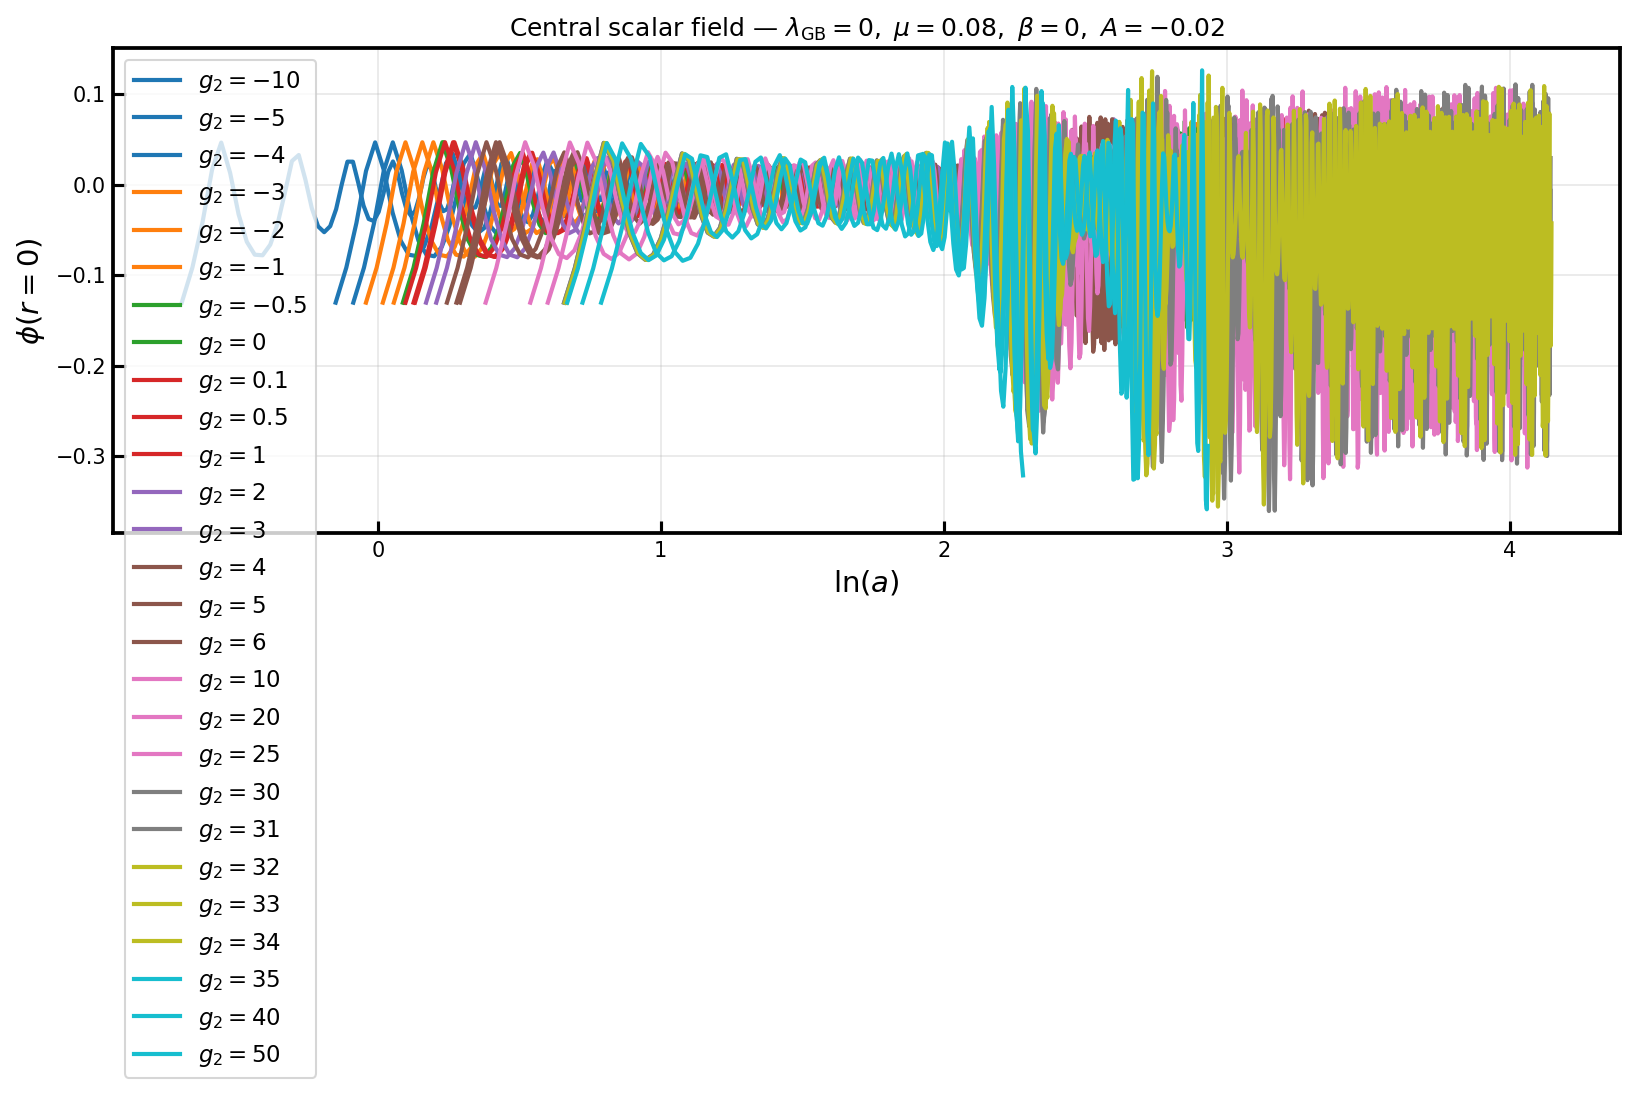

In [15]:
# Central scalar field φ(r=0) vs ln(a) for each g2 value

matching_runs = []
for key in sorted(all_runs.keys(), key=lambda k: tuple(x if x is not None else -999 for x in k)):
    lgb, mu, beta, amp, width, g2 = key
    if lgb != lgb_plot or mu != mu_plot or amp != amp_plot or width != width_plot:
        continue
    if beta != beta_plot:
        continue
    matching_runs.append((key, all_runs[key]))

n_runs = len(matching_runs)
cmap_g2 = plt.cm.tab10

fig, ax = plt.subplots(figsize=(11, 6))

for i_run, (key, data) in enumerate(matching_runs):
    lgb, mu, beta, amp, width, g2 = key
    osc = data["osc"]
    r_grid = osc["r"]
    s_ln_a = data["shifted_ln_a"]

    run_dir = os.path.join(DATA_DIR, data["tag"])
    sol = np.load(os.path.join(run_dir, "solution.npy"))
    N_grid = len(r_grid)
    NUM_VARS = sol.shape[1] // N_grid

    i_r0 = np.argmin(np.abs(r_grid))
    phi_central = np.array([sol[t].reshape(NUM_VARS, N_grid)[12, i_r0] for t in range(sol.shape[0])])
    del sol

    color = cmap_g2(i_run / max(n_runs - 1, 1))
    ax.plot(s_ln_a, phi_central, color=color, lw=2,
            label=rf"$g_2={g2:g}$")

beta_str = "linear" if beta_plot is None else rf"\beta={beta_plot}"
ax.set_xlabel(r"$\ln(a)$", fontsize=14)
ax.set_ylabel(r"$\phi(r=0)$", fontsize=14)
ax.set_title(rf"Central scalar field — $\lambda_{{\rm GB}}={lgb_plot},\ \mu={mu_plot},\ {beta_str},\ A={amp_plot}$", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 8 — Compactness vs $\lambda_{\rm GB}$ for each $g_2$

Mean compactness (with min–max error bars) in the shifted window
$[$ `LN_A_COMP_MIN` $,$ `LN_A_COMP_MAX` $]$, one curve per $g_2$ value.

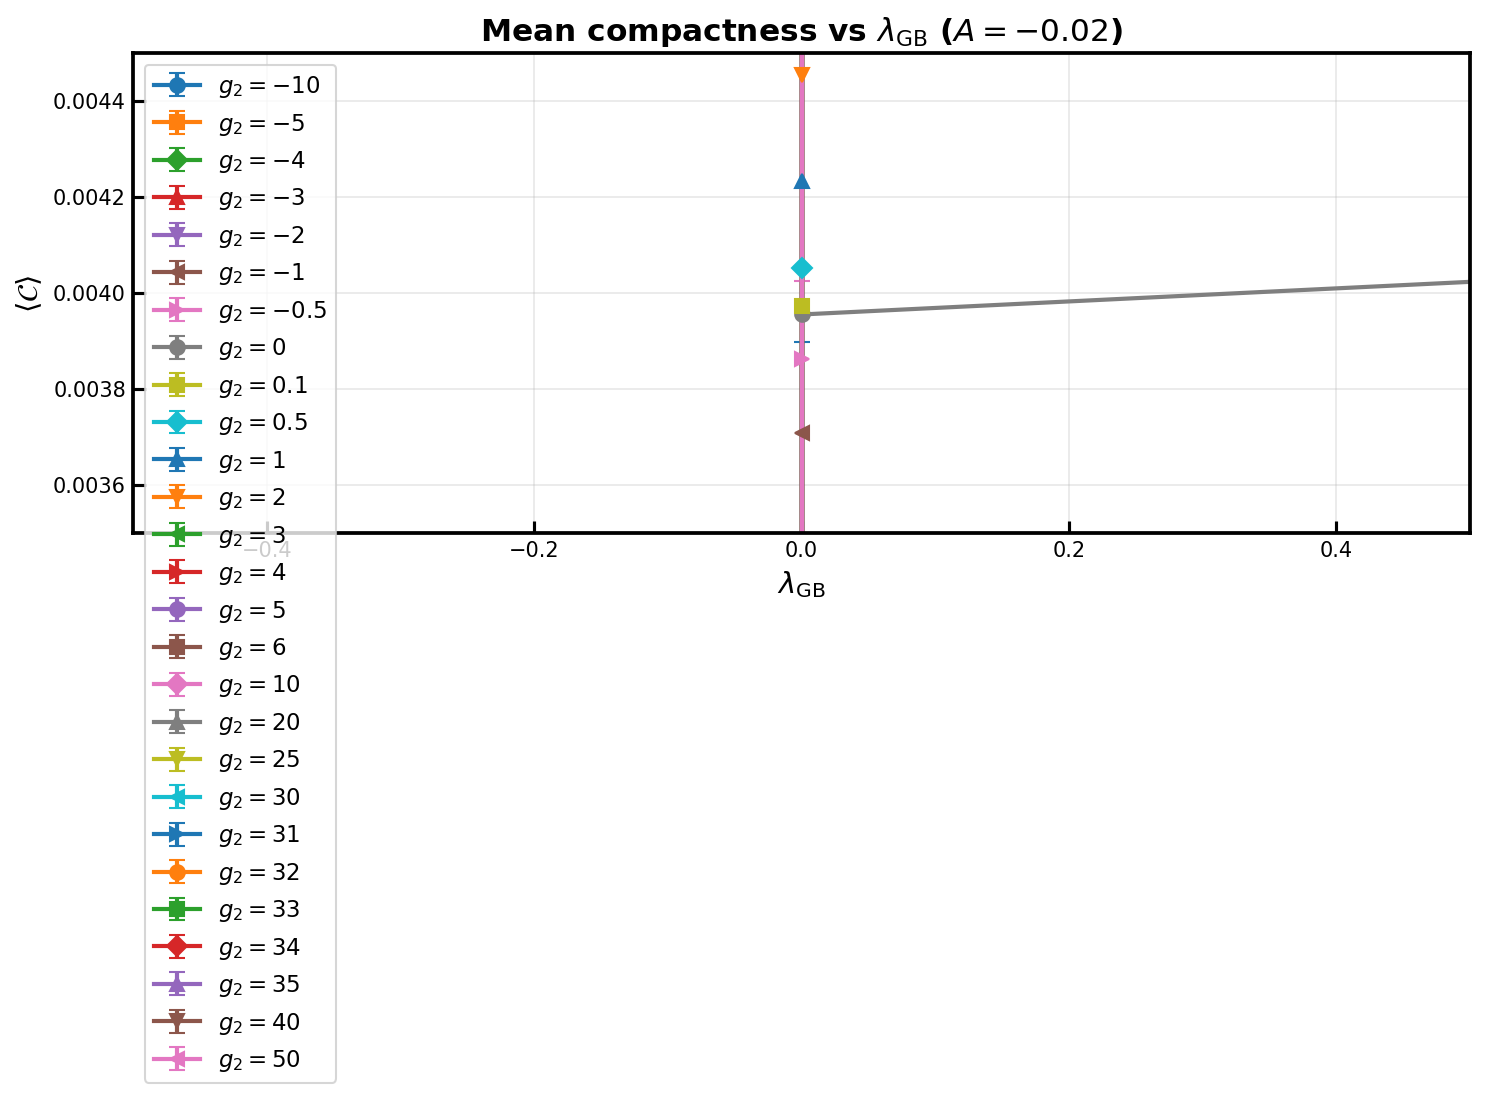

In [16]:
SAVE_PDF = False

plt.rcParams.update({
    "axes.linewidth": 1.8,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
})

fig, ax = plt.subplots(figsize=(10, 6))
markers = ["o", "s", "D", "^", "v", "<", ">"]

for ig, g2_val in enumerate(all_g2):
    lgbs, means, stds = [], [], []
    for key in sorted(all_runs.keys(), key=lambda k: tuple(x if x is not None else -999 for x in k)):
        lgb, mu, beta, amp, width, g2 = key
        if g2 != g2_val or amp != DEFAULT_AMP:
            continue
        if beta not in betas or mu not in mu_values or width != DEFAULT_WIDTH:
            continue
        d = all_runs[key]
        if np.isnan(d["C_mean"]):
            continue
        lgbs.append(lgb)
        means.append(d["C_mean"])
        stds.append(d["C_std"])

    if not lgbs:
        continue
    ax.errorbar(lgbs, means, yerr=stds,
                fmt=markers[ig % len(markers)] + "-",
                capsize=4, lw=2, markersize=7,
                label=rf"$g_2 = {g2_val:g}$")

ax.set_xlim(-0.5,0.5)
ax.set_ylim(0.0035, 0.0045)

ax.set_xlabel(r"$\lambda_{\rm GB}$", fontsize=14)
ax.set_ylabel(r"$\langle\mathcal{C}\rangle$", fontsize=14)
ax.set_title(rf"Mean compactness vs $\lambda_{{\rm GB}}$ ($A={DEFAULT_AMP}$)",
             fontsize=15, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()

if SAVE_PDF:
    fig.savefig("compactness_vs_lambda_g2.pdf", bbox_inches="tight")
    print("Saved compactness_vs_lambda_g2.pdf")

plt.show()

## 9 — Paper-style diagnostics (single run)

Four-panel figure for a chosen `(lgb, mu, beta, amp, width, g2)` key.

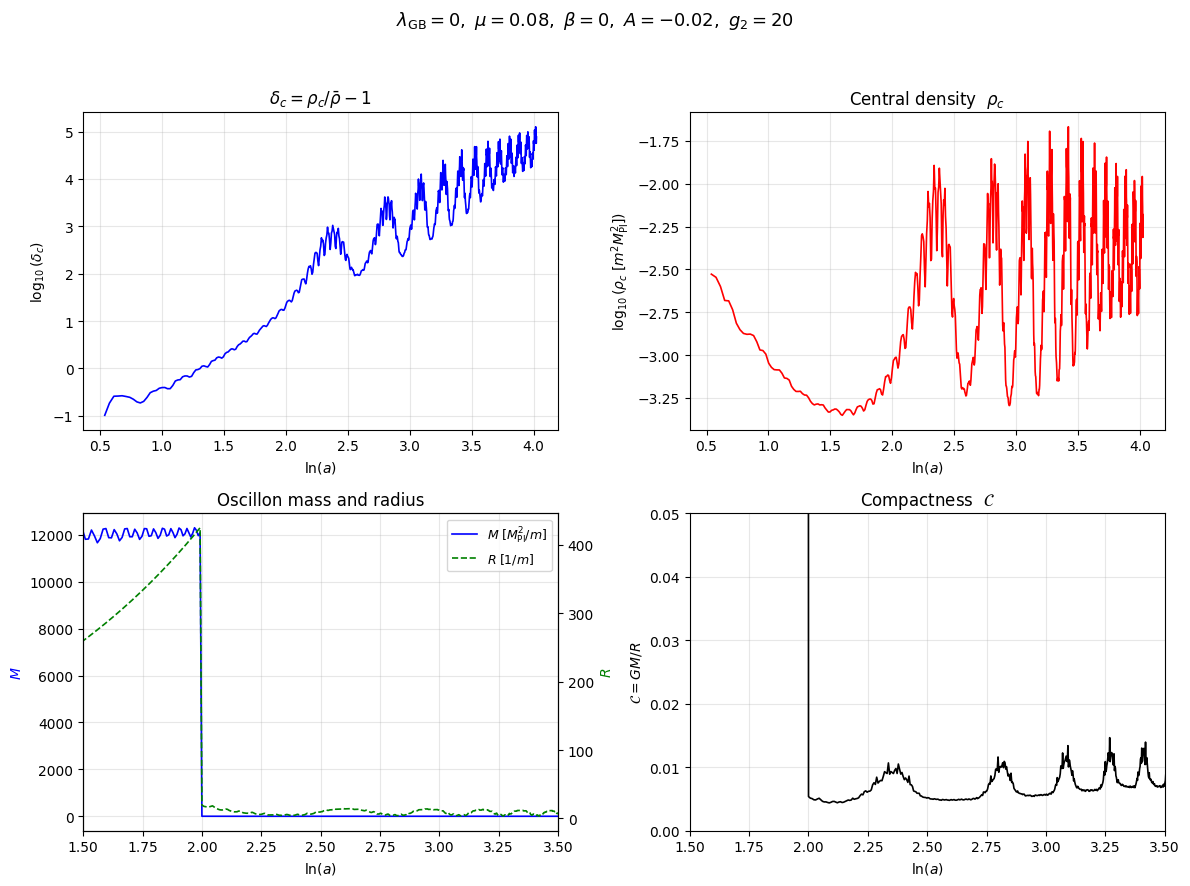

In [10]:
from bssn.oscillondiagnostic import plot_paper_diagnostics

lgb_inspect   = 0
mu_inspect    = 0.08
beta_inspect  = 0
amp_inspect   = -0.02
width_inspect = 3.0
g2_inspect    = 20

inspect_key = (lgb_inspect, mu_inspect, beta_inspect, amp_inspect, width_inspect, g2_inspect)

if inspect_key not in all_runs:
    print(f"Key {inspect_key} not found in all_runs.")
    print(f"Available keys:\n  " + "\n  ".join(str(k) for k in sorted(all_runs.keys(), key=lambda k: tuple(x if x is not None else -999 for x in k))))
else:
    run = all_runs[inspect_key]
    osc_shifted = {**run["osc"], "ln_a": run["shifted_ln_a"]}

    fig, axes = plot_paper_diagnostics(osc_shifted)
    fig.suptitle(
        rf"$\lambda_{{\rm GB}} = {lgb_inspect},\ \mu = {mu_inspect},"
        rf"\ \beta = {beta_inspect},\ A = {amp_inspect},\ g_2 = {g2_inspect}$",
        fontsize=13,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

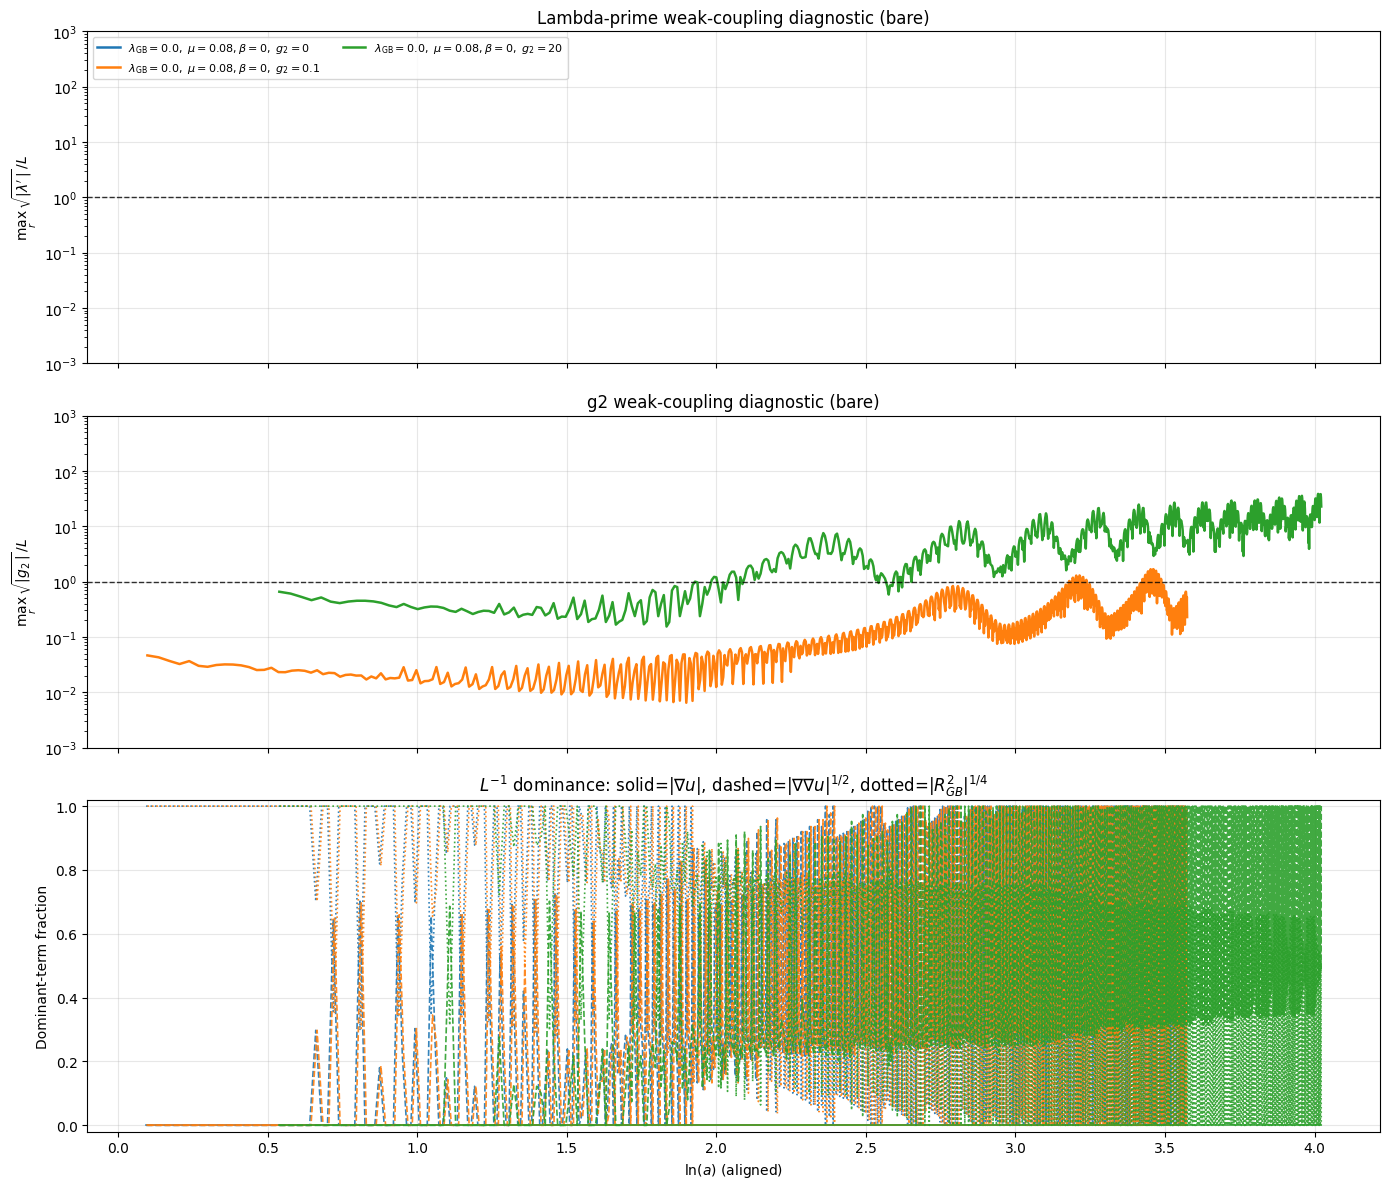

Finite arrays check: True
Dominance consistency check: False
Sample ranges (first selected run):
  L_inv: [3.067e-03, 5.356e+00]
  wc_lambda_bare max: 0.000e+00
  wc_g2_bare max:     0.000e+00


In [9]:
# ## 10 — EFT weak-coupling diagnostics
# Tracks:
#  - wc_lambda = sqrt(|lambda'|) /L
#  - wc_g2     = sqrt(|g2|) / L
# Bare (paper/GRChombo) conventions only — the sigmoid- and Sigma-dressed
# "code" versions are not physical comparables and have been removed.

USE_ALIGNED_EFT = True
R_EFT_MAX = 100.0

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
cmap = plt.cm.tab10

if len(keys_to_plot) == 0:
    print("No keys_to_plot selected.")
else:
    first_key = keys_to_plot[0]
    eft0 = all_runs[first_key]["eft"]
    r0 = eft0["r"]
    r_mask = (r0 > 0) & (r0 <= R_EFT_MAX)

    for i, key in enumerate(keys_to_plot):
        if key not in all_runs:
            continue
        run = all_runs[key]
        eft = run.get("eft", None)
        if eft is None:
            continue

        lgb, mu, beta, amp, width, g2 = key
        beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str},\ g_2={g2:g}$"

        x = run["shifted_ln_a"] if USE_ALIGNED_EFT else run["osc"]["ln_a"]
        color = cmap(i % 10)

        wc_lambda_bare_max = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
        wc_g2_bare_max = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)

        axes[0].plot(x, wc_lambda_bare_max, color=color, lw=1.8, label=label)
        axes[1].plot(x, wc_g2_bare_max, color=color, lw=1.8, label=label)

        dom = eft["dominant_term_idx"][:, r_mask]
        frac_grad = np.mean(dom == 0, axis=1)
        frac_hess = np.mean(dom == 1, axis=1)
        frac_gb = np.mean(dom == 2, axis=1)

        axes[2].plot(x, frac_grad, color=color, lw=1.2, alpha=0.9)
        axes[2].plot(x, frac_hess, color=color, lw=1.2, ls="--", alpha=0.9)
        axes[2].plot(x, frac_gb, color=color, lw=1.2, ls=":", alpha=0.9)

    axes[0].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[1].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.8)

    axes[0].set_ylabel(r"$\max_r\,\sqrt{|\lambda'|}\,/L$")
    axes[0].set_title("Lambda-prime weak-coupling diagnostic (bare)")
    axes[0].set_yscale("log")
    axes[0].set_ylim(1e-3, 1e3)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel(r"$\max_r\,\sqrt{|g_2|}\,/L$")
    axes[1].set_title("g2 weak-coupling diagnostic (bare)")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-3, 1e3)
    axes[1].grid(True, alpha=0.3)

    axes[2].set_ylabel("Dominant-term fraction")
    axes[2].set_ylim(-0.02, 1.02)
    axes[2].set_title(r"$L^{-1}$ dominance: solid=$|\nabla u|$, dashed=$|\nabla\nabla u|^{1/2}$, dotted=$|R_{GB}^2|^{1/4}$")
    axes[2].grid(True, alpha=0.3)

    axes[2].set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED_EFT else ""))
    axes[0].legend(fontsize=8, ncol=2, loc="upper left")

    fig.tight_layout()
    plt.show()

    # --- sanity checks on the first selected run ---
    dcheck = all_runs[first_key]["eft"]
    finite_ok = (
        np.isfinite(dcheck["L_inv"]).all()
        and np.isfinite(dcheck["wc_lambda_bare"]).all()
        and np.isfinite(dcheck["wc_g2_bare"]).all()
    )
    print(f"Finite arrays check: {finite_ok}")

    terms = np.stack([
        dcheck["term_grad_u"],
        dcheck["term_hess_u_sqrt"],
        dcheck["term_gb_quarter"],
    ], axis=0)
    dom_from_terms = np.argmax(terms, axis=0)
    dom_match = np.array_equal(dom_from_terms, dcheck["dominant_term_idx"])
    print(f"Dominance consistency check: {dom_match}")

    print("Sample ranges (first selected run):")
    print(f"  L_inv: [{np.nanmin(dcheck['L_inv']):.3e}, {np.nanmax(dcheck['L_inv']):.3e}]")
    print(f"  wc_lambda_bare max: {np.nanmax(dcheck['wc_lambda_bare']):.3e}")
    print(f"  wc_g2_bare max:     {np.nanmax(dcheck['wc_g2_bare']):.3e}")


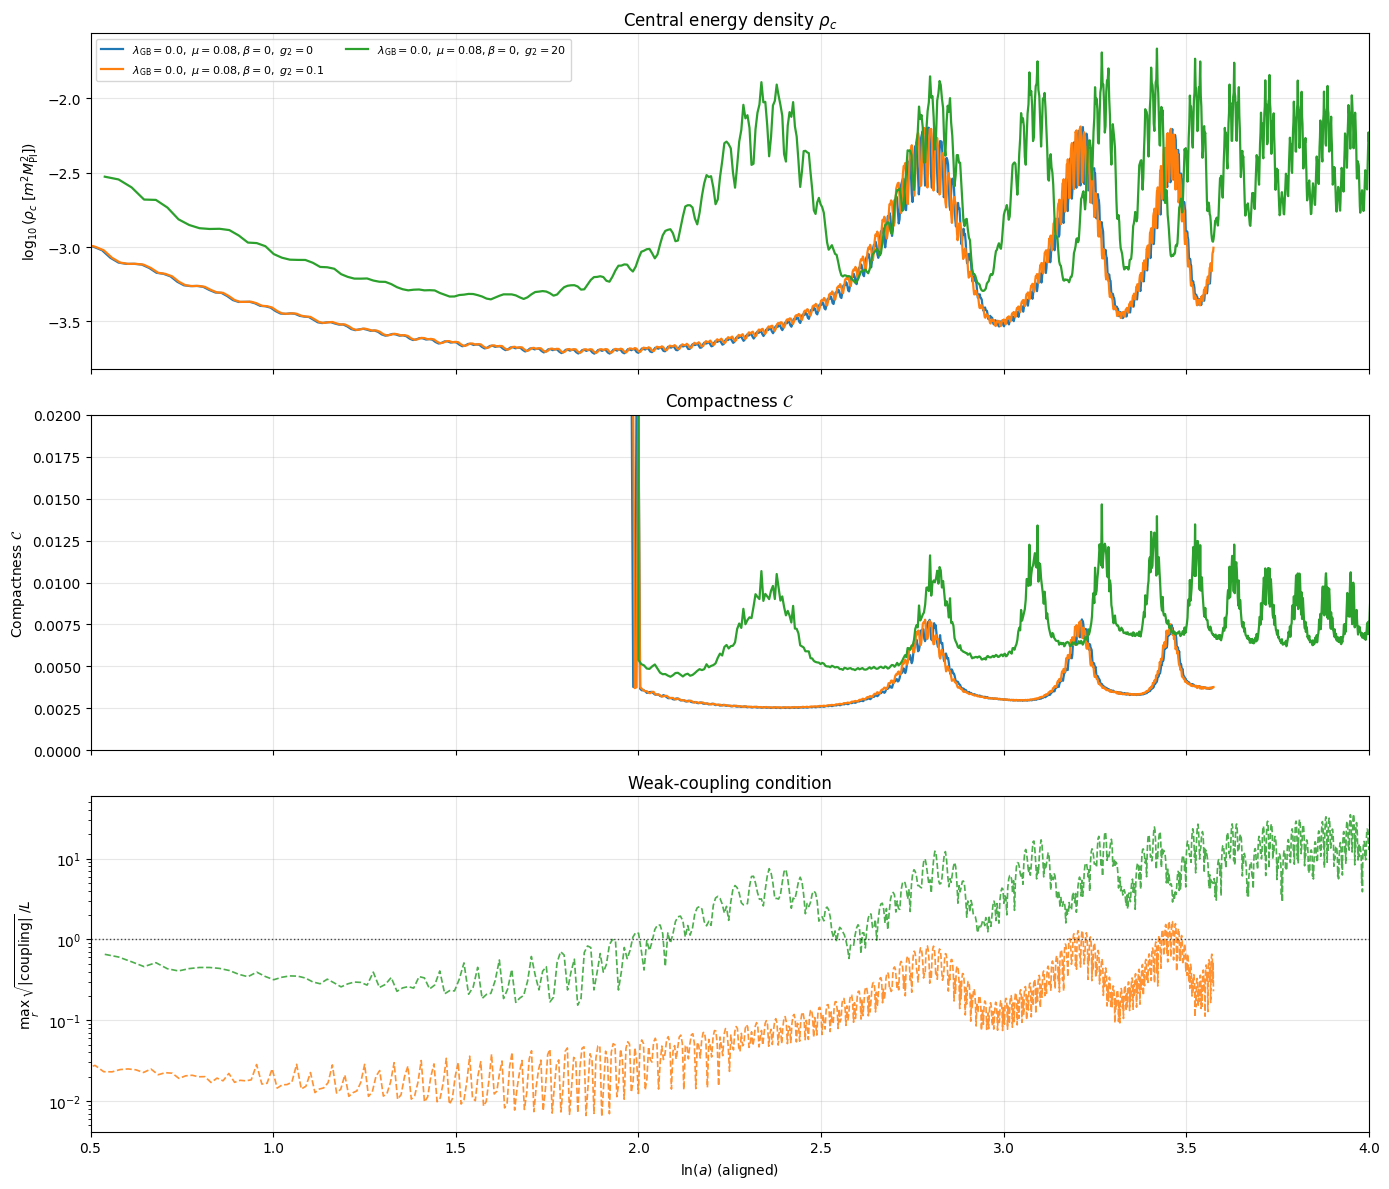

In [16]:
# ## 11 — rho_c, compactness and WCC vs ln(a)
# Three stacked panels sharing x-axis:
#   top    : log10(rho_c)
#   middle : compactness C
#   bottom : weak-coupling condition max_r(sqrt(|lambda'|)/L)  (and sqrt(|g2|)/L if nonzero)

USE_ALIGNED_COMBO = True
R_WCC_MAX = 100.0

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
cmap = plt.cm.tab10

if len(keys_to_plot) == 0:
    print("No keys_to_plot selected.")
else:
    first_key = keys_to_plot[0]
    eft0 = all_runs[first_key].get("eft", None)
    r0 = eft0["r"] if eft0 is not None else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX) if r0 is not None else None

    any_g2_nonzero = False
    for i, key in enumerate(keys_to_plot):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)

        lgb, mu, beta, amp, width, g2 = key
        beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str},\ g_2={g2:g}$"
        color = cmap(i % 10)

        x = run["shifted_ln_a"] if USE_ALIGNED_COMBO else osc["ln_a"]

        # Panel 1: log10(rho_c)
        rho_c = osc["rho_c"]
        pos = rho_c > 0
        y_rho = np.full_like(rho_c, np.nan, dtype=float)
        y_rho[pos] = np.log10(rho_c[pos])
        axes[0].plot(x, y_rho, color=color, lw=1.6, label=label)

        # Panel 2: compactness
        axes[1].plot(x, osc["C"], color=color, lw=1.6, label=label)

        # Panel 3: weak-coupling conditions
        if eft is not None:
            wc_lam = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
            axes[2].plot(x, wc_lam, color=color, lw=1.8, label=label)
            if g2 != 0:
                wc_g2 = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)
                axes[2].plot(x, wc_g2, color=color, lw=1.2, ls="--", alpha=0.85)
                any_g2_nonzero = True

    axes[0].set_ylabel(r"$\log_{10}(\rho_c \; [m^2 M_{\rm Pl}^2])$")
    axes[0].set_title(r"Central energy density $\rho_c$")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0.5, 4)

    axes[1].set_ylabel(r"Compactness $\mathcal{C}$")
    axes[1].set_title(r"Compactness $\mathcal{C}$")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 0.02)

    axes[2].axhline(1.0, color="k", lw=1.0, ls=":", alpha=0.7)
    axes[2].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,/L$")
    wcc_title = r"Weak-coupling condition"
    axes[2].set_title(wcc_title)
    axes[2].set_yscale("log")
    axes[2].grid(True, alpha=0.3)

    axes[2].set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED_COMBO else ""))
    axes[0].legend(fontsize=8, ncol=2, loc="best")

    fig.tight_layout()
    plt.show()